[Font] 正在下载中文字体 NotoSansSC...
[Font] 已下载并注册中文字体: Noto Sans SC
检测到 Google Drive，结果将保存至: /content/drive/MyDrive/实验16_4_扩散先验重建
使用设备: cpu
步骤1：DDPM训练（回顾第11章）
  ↳ 检测到已有checkpoint，从第 50 轮继续训练
  DDPM 模型已训练完毕，跳过。

步骤2：DiffPIR for MRI（16.5.2节）

步骤3：DPS for MRI（16.5.3节）

步骤4：方法对比与不确定性量化（16.5.4节）
  正在执行DiffPIR重建...
  正在执行DPS重建 (zeta=0.3, 线性衰减)...

  PSNR对比:
  样本0: 零填充=11.3dB, DiffPIR=11.1dB, DPS=8.8dB
  样本1: 零填充=9.1dB, DiffPIR=8.3dB, DPS=8.0dB
  样本2: 零填充=14.1dB, DiffPIR=11.3dB, DPS=11.4dB
  样本3: 零填充=7.8dB, DiffPIR=9.1dB, DPS=8.2dB

  ζ敏感性分析:
    ζ=0.1: PSNR=9.9dB
    ζ=0.3: PSNR=9.5dB
    ζ=0.5: PSNR=10.1dB
    ζ=1.0: PSNR=9.6dB

  正在计算不确定性量化（15次DPS采样, ζ=0.5）...
    采样 1/15...
    采样 2/15...
    采样 3/15...
    采样 4/15...
    采样 5/15...
    采样 6/15...
    采样 7/15...
    采样 8/15...
    采样 9/15...
    采样 10/15...
    采样 11/15...
    采样 12/15...
    采样 13/15...
    采样 14/15...
    采样 15/15...
  单次采样PSNR: 9.9dB
  后验均值PSNR: 13.1dB (提升 +3.2dB)

  正在计算DiffPIR不确定性量化（15次采样）...
    DiffPIR采样 1/15...
    Diff

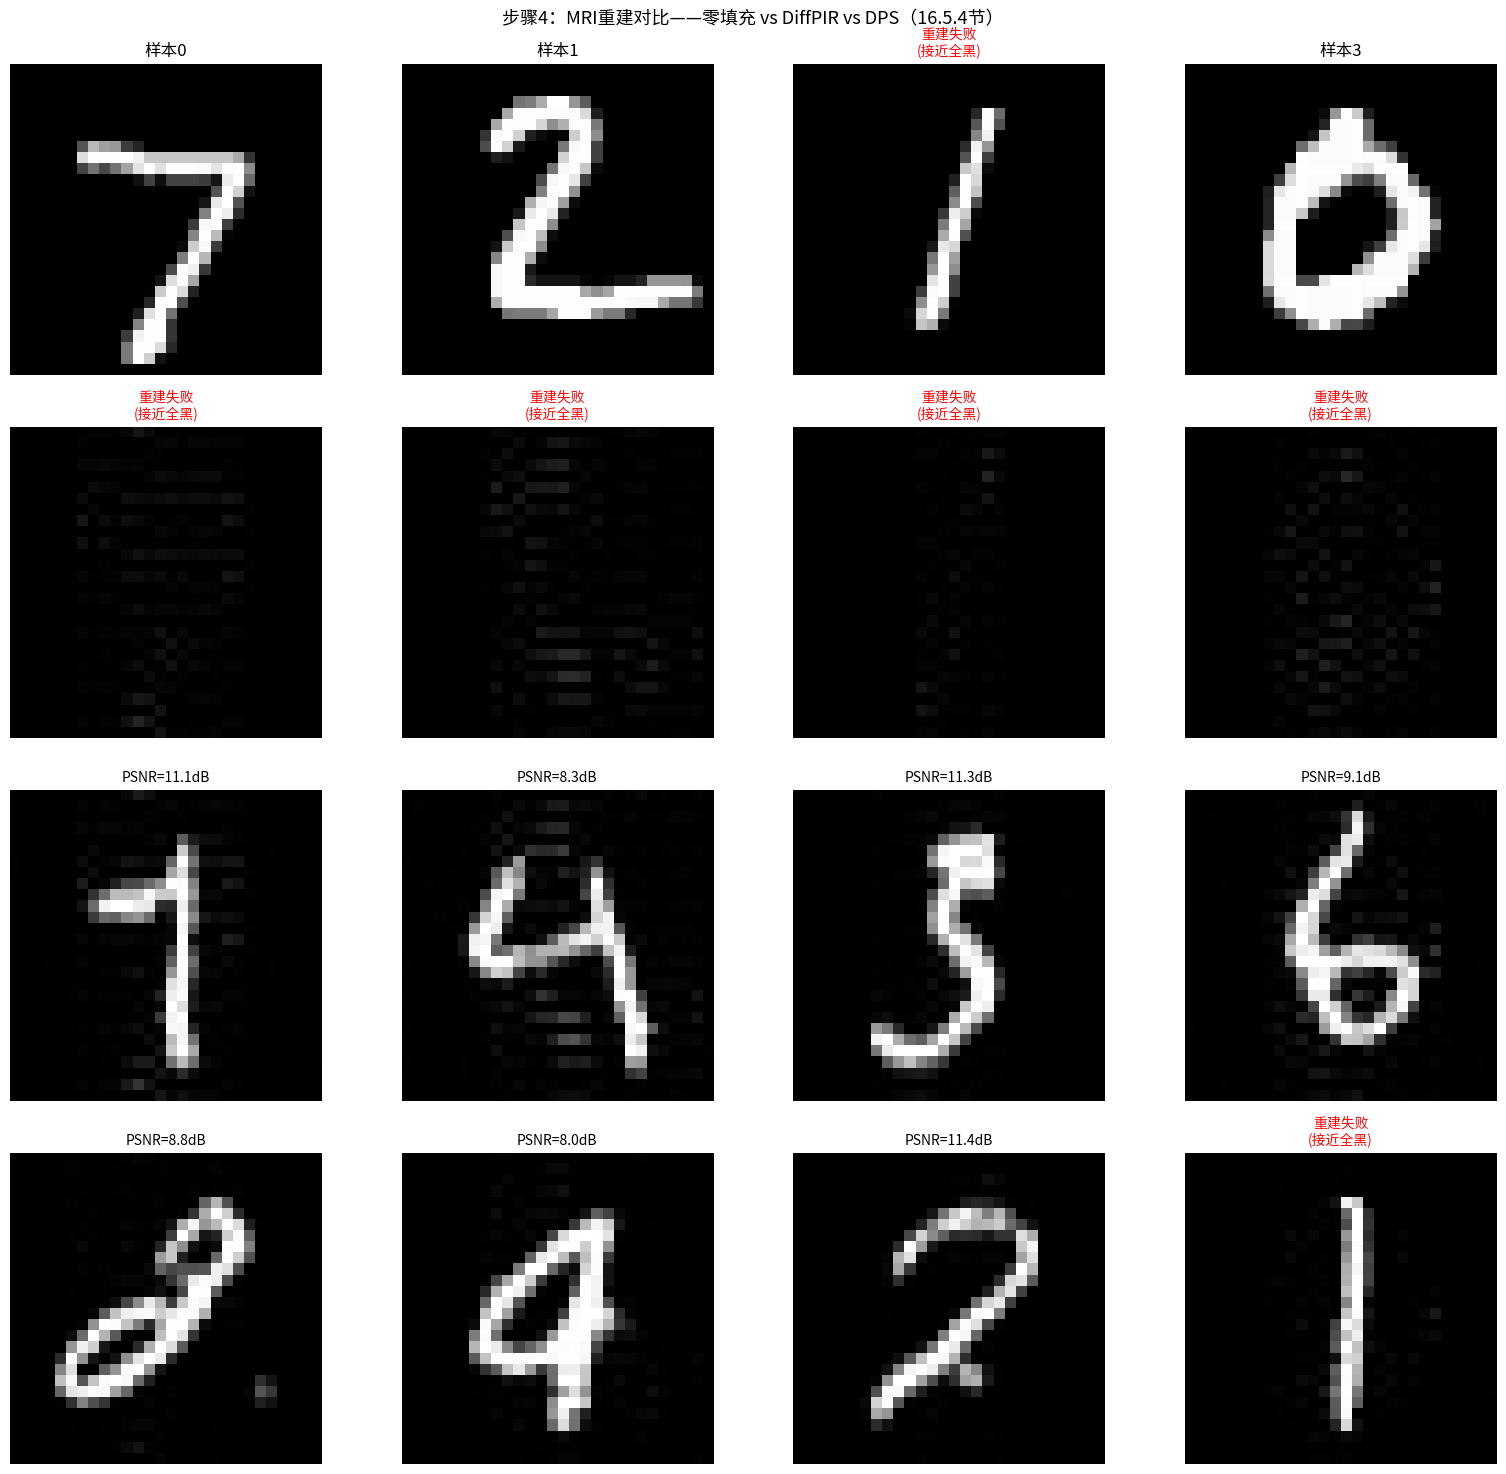

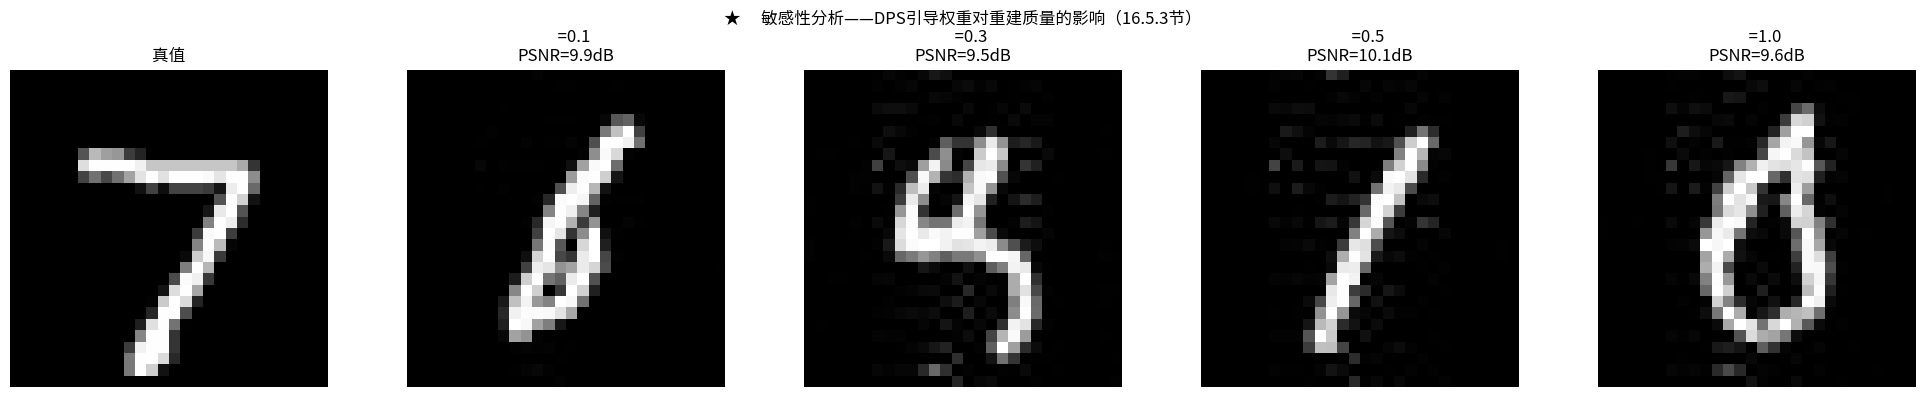

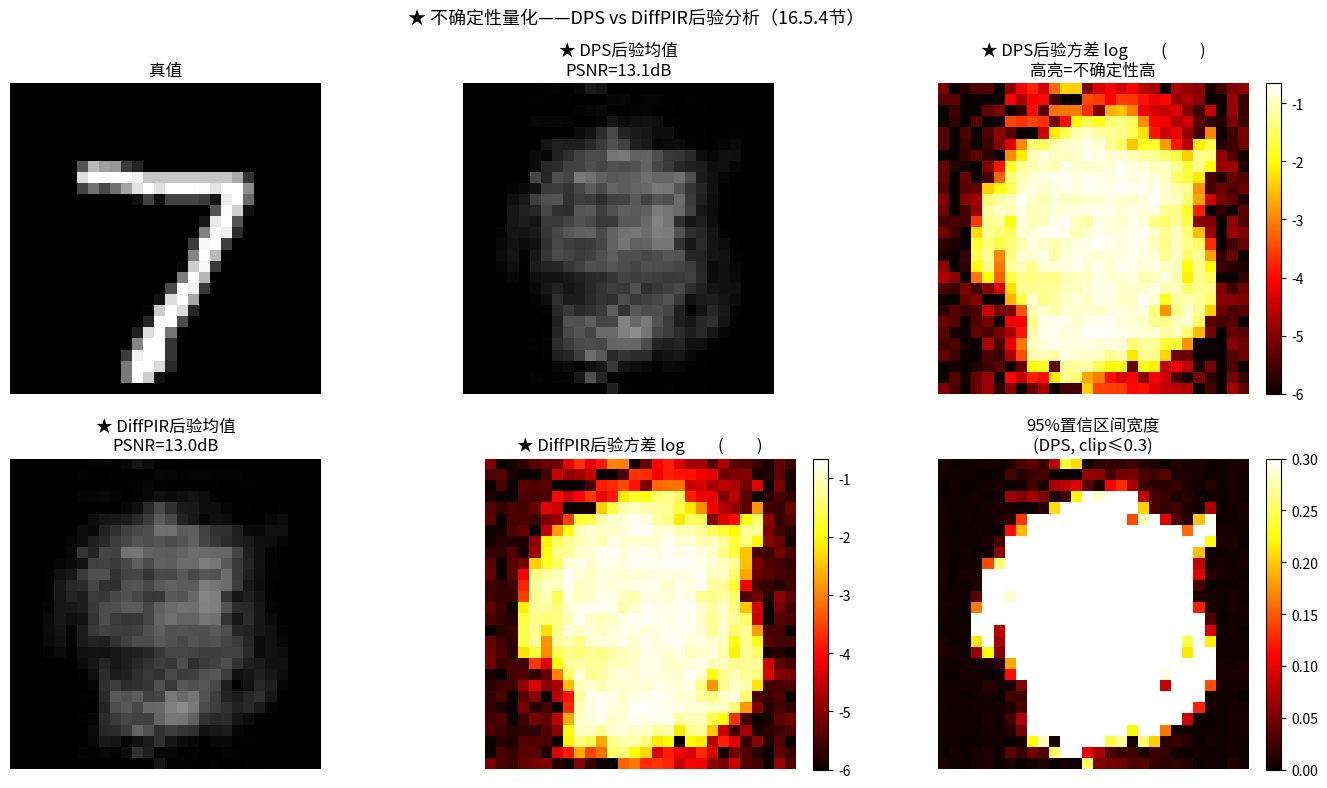

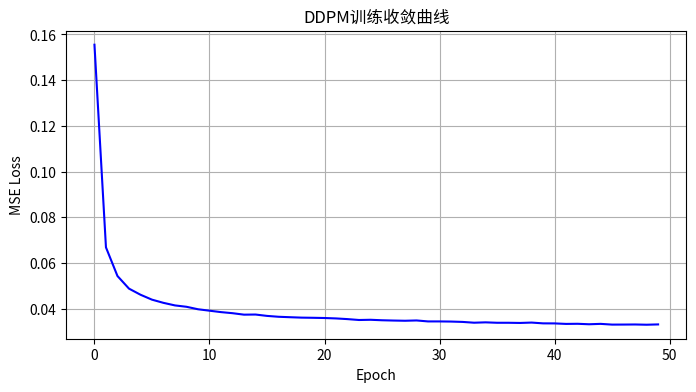


实验16.4完成！


In [ ]:
# -*- coding: utf-8 -*-
"""
实验16.4 扩散先验重建
对应知识点：16.5.1节（从传统先验到扩散先验）
           16.5.2节（DiffPIR for CT/MRI）
           16.5.3节（DPS for CT/MRI）
           16.5.4节（方法对比与不确定性量化）

★原创设计：
- 在MNIST上训练DDPM，然后使用DPS求解MRI逆问题
- MRI正向算子结构使得数据一致性步极其高效
- 实现不确定性量化（多次后验采样→像素级方差）
- 无需deepinv库，纯PyTorch实现

素材来源：DDPM训练框架复用自11.2.py，DPS采样参考13.2.py
运行前提：需GPU
"""

import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Noto Sans SC',
            'Source Han Sans SC', 'AR PL UMing CN', 'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os as _os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*sc', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (_os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    # Linux/Colab 未找到中文字体，尝试下载 Noto Sans SC
    if platform.system() != 'Windows':
        _font_url = 'https://github.com/jsntn/webfonts/raw/master/NotoSansSC-Regular.ttf'
        _font_file = os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.', 'NotoSansSC-Regular.ttf')
        try:
            import urllib.request
            print(f"[Font] 正在下载中文字体 NotoSansSC...")
            urllib.request.urlretrieve(_font_url, _font_file)
            from matplotlib.font_manager import fontManager
            fontManager.addfont(_font_file)
            plt.rcParams['font.sans-serif'] = ['Noto Sans SC'] + plt.rcParams.get('font.sans-serif', [])
            plt.rcParams['font.family'] = 'sans-serif'
            _cn_font = 'Noto Sans SC'
            print(f"[Font] 已下载并注册中文字体: {_cn_font}")
        except Exception as e:
            print(f"[Font] 字体下载失败: {e}，中文可能显示为方框")
    else:
        print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

_gdrive = '/content/drive/MyDrive'
if os.path.isdir(_gdrive):
    SAVE_DIR = os.path.join(_gdrive, '实验16_4_扩散先验重建')
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"检测到 Google Drive，结果将保存至: {SAVE_DIR}")
else:
    SAVE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    print(f"本地环境，结果将保存至: {SAVE_DIR}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


# ========================================================================
# DDPM噪声调度（T=200, 复用自11.2.py/14.2.py）
# ========================================================================
T = 200
beta_min, beta_max = 1e-4, 0.02
betas = torch.linspace(beta_min, beta_max, T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
beta_over_sqrt_1m_ab = betas / sqrt_one_minus_alpha_bars

# 后验分布系数
posterior_variance = betas * (1.0 - alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_variance[0] = betas[0]
posterior_log_variance = torch.log(torch.clamp(posterior_variance, min=1e-20))
posterior_mean_coef1 = betas * torch.sqrt(alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_mean_coef2 = (1.0 - alpha_bars.roll(1, 0)) * torch.sqrt(alphas) / (1.0 - alpha_bars)
# 修正t=0
posterior_mean_coef1[0] = 0.0
posterior_mean_coef2[0] = 1.0


# ========================================================================
# SmallUNet去噪网络（复用自11.2.py）
# ========================================================================
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.log(torch.tensor(10000.0)) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=64):
        super().__init__()
        gn_groups = min(4, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(gn_groups, out_ch)
        self.norm2 = nn.GroupNorm(gn_groups, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.shortcut(x)


class SmallUNet(nn.Module):
    """小型UNet去噪网络（适配MNIST 28x28, ε-prediction）"""
    def __init__(self, time_dim=64):
        super().__init__()
        ch = [1, 16, 32, 64]
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
        self.down1 = ConvBlock(ch[0], ch[1], time_dim)
        self.down2 = ConvBlock(ch[1], ch[2], time_dim)
        self.down3 = ConvBlock(ch[2], ch[3], time_dim)
        self.bottleneck = ConvBlock(ch[3], ch[3], time_dim)
        self.up3 = ConvBlock(ch[3] + ch[2], ch[2], time_dim)
        self.up2 = ConvBlock(ch[2] + ch[1], ch[1], time_dim)
        self.up1 = ConvBlock(ch[1] + ch[0], ch[0], time_dim)
        self.out_conv = nn.Conv2d(ch[0], 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x_t, t):
        t_emb = self.time_mlp(t)
        h1 = self.down1(x_t, t_emb)
        h2 = self.down2(self.pool(h1), t_emb)
        h3 = self.down3(self.pool(h2), t_emb)
        h = self.bottleneck(h3, t_emb)
        h = F.interpolate(h, size=(14, 14), mode='nearest')
        h = self.up3(torch.cat([h, h2], dim=1), t_emb)
        h = F.interpolate(h, size=(28, 28), mode='nearest')
        h = self.up2(torch.cat([h, h1], dim=1), t_emb)
        h = self.up1(torch.cat([h, x_t], dim=1), t_emb)
        return self.out_conv(h)


# ========================================================================
# MRI正向算子
# ========================================================================
class MRIFourierOperator:
    """MRI欠采样傅里叶算子"""
    def __init__(self, mask):
        self.mask = mask  # (H,)

    def A(self, x):
        B, C, H, W = x.shape
        kspace = torch.fft.fft2(x)
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(x.device)
        return kspace * mask_2d

    def AT(self, y):
        B, C, H, W = y.shape
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(y.device)
        return torch.real(torch.fft.ifft2(y * mask_2d))

    def data_consistency(self, x, y, zeta=1.0):
        """
        ★ MRI数据一致性步（16.5.2节）
        由于 F^H F = I，数据一致性步简化为：
        - 已采样位置: 替换为测量值
        - 未采样位置: 保持扩散模型预测
        """
        kspace_pred = torch.fft.fft2(x)
        kspace_corrected = kspace_pred.clone()
        # 在已采样位置混合
        mask_2d = self.mask.view(1, 1, x.shape[2], 1).expand_as(kspace_pred).to(x.device)
        kspace_corrected = mask_2d * (kspace_pred + zeta * (y - kspace_pred * mask_2d)) + (1 - mask_2d) * kspace_pred
        return torch.real(torch.fft.ifft2(kspace_corrected))


def create_mri_mask(n_rows, R, seed=42):
    """创建可变密度1D采样掩码"""
    torch.manual_seed(seed)
    n_sample = max(n_rows // R, 1)
    prob = torch.zeros(n_rows)
    for i in range(n_rows):
        dist = abs(i - n_rows // 2) / (n_rows // 2)
        prob[i] = (1 - dist ** 2) ** 1.5 + 0.02
    prob = prob / prob.sum() * n_sample
    mask = torch.zeros(n_rows)
    sorted_idx = torch.argsort(prob, descending=True)
    mask[sorted_idx[:n_sample]] = 1
    mask[n_rows // 2] = 1
    return mask


# ========================================================================
# DDPM训练
# ========================================================================
print("=" * 60)
print("步骤1：DDPM训练（回顾第11章）")
print("=" * 60)

data_dir = os.path.join(SAVE_DIR, 'data')
dataset = datasets.MNIST(data_dir, train=True, download=True,
                         transform=transforms.Compose([
                             transforms.Resize(28),
                             transforms.ToTensor(),
                         ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)

model = SmallUNet(time_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-4)

n_epochs = 50
train_losses = []

# ★ Resume: 检测已有checkpoint，支持断点续训
ddpm_ckpt_path = os.path.join(SAVE_DIR, 'ddpm_ckpt.pt')
start_epoch = 0
if os.path.exists(ddpm_ckpt_path):
    ckpt = torch.load(ddpm_ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    train_losses = ckpt.get('losses', [])
    print(f"  ↳ 检测到已有checkpoint，从第 {start_epoch} 轮继续训练")

if start_epoch >= n_epochs:
    print("  DDPM 模型已训练完毕，跳过。")
else:
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        n_batches = 0
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            B = batch_x.shape[0]

            # 随机采样时间步
            t = torch.randint(0, T, (B,), device=device)

            # 前向过程: x_t = sqrt(ᾱ_t) * x_0 + sqrt(1-ᾱ_t) * ε
            noise = torch.randn_like(batch_x)
            x_t = (sqrt_alpha_bars[t].view(B, 1, 1, 1) * batch_x +
                   sqrt_one_minus_alpha_bars[t].view(B, 1, 1, 1) * noise)

            # 预测噪声
            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, Loss={avg_loss:.4f}")

        # 每10轮保存checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'losses': train_losses,
            }, ddpm_ckpt_path)
            print(f"  ✓ checkpoint已保存 (epoch {epoch+1})")

    print(f"  DDPM训练完成，最终Loss={train_losses[-1]:.4f}")


# ========================================================================
# DDPM反向采样
# ========================================================================
@torch.no_grad()
def ddpm_sample(model, shape):
    """标准DDPM反向采样"""
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)
        pred_noise = model(x, t)
        # μ_θ = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε̂)
        model_mean = sqrt_recip_alphas[t_idx] * (x - beta_over_sqrt_1m_ab[t_idx] * pred_noise)
        if t_idx > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = model_mean
    return x


# ========================================================================
# Tweedie预测
# ========================================================================
def tweedie_predict(x_t, t_idx):
    """从x_t和噪声预测预测x_0: x̂_0 = (x_t - √(1-ᾱ_t)·ε̂) / √ᾱ_t

    ★ 数值稳定化：当ᾱ_t很小时（大t），Tweedie估计会爆炸，
      用soft clamp限制x0_hat的范围，避免clamp(0,1)后全黑

    Returns:
        x0_hat: Tweedie估计的干净图像
        pred_noise: 模型预测的噪声（可复用，避免重复前向）
    """
    t = torch.full((x_t.shape[0],), t_idx, device=device, dtype=torch.long)
    pred_noise = model(x_t, t)
    # 数值稳定化：先除以clamped的√ᾱ_t，避免除零
    sqrt_ab = sqrt_alpha_bars[t_idx].clamp(min=1e-3)
    x0_hat = (x_t - sqrt_one_minus_alpha_bars[t_idx] * pred_noise) / sqrt_ab
    # soft clamp: 限制到[-2, 2]而不是直接[0,1]，避免梯度消失
    x0_hat = x0_hat.clamp(-2, 2)
    return x0_hat, pred_noise


# ========================================================================
# ★ 步骤2：DiffPIR for MRI（16.5.2节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤2：DiffPIR for MRI（16.5.2节）")
print("=" * 60)

@torch.no_grad()
def diffpir_mri(model, y, mri_op, shape, zeta=1.0):
    """
    ★ 修正版 DiffPIR算法 for MRI（16.5.2节）:
    对 t = T-1, T-2, ..., 0:
      1. 预测干净图像: x̂_{0|t} = Tweedie(x_t, t)
      2. 数据一致性步: x̂'_{0|t} = DC(x̂_{0|t}, y)  (仅小t时启用)
      3. 利用DDPM后验公式 q(x_{t-1}|x_t, x̂'_0) 从 x_t 推进到 x_{t-1}
         μ̃_t = coef1_t * x̂'_0 + coef2_t * x_t

    ★ 关键修正：
    - 大t时Tweedie估计不可靠，跳过DC步，使用纯后验公式
    - 小t时Tweedie估计可靠，DC步提供数据一致性约束
    - dc_weight从t=T/2开始线性增长到1，避免早期垃圾估计污染采样
    """
    model.eval()
    x = torch.randn(shape, device=device)

    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)

        # 1. 预测干净图像（Tweedie公式，已含数值稳定化）
        x0_hat, _ = tweedie_predict(x, t_idx)
        x0_hat = x0_hat.clamp(0, 1)

        # 2. 数据一致性步（仅在Tweedie可靠时启用）
        #    dc_weight: t_idx大→0（Tweedie不准），t_idx小→1（Tweedie准）
        dc_weight = max(0.0, 1.0 - t_idx / (T * 0.5))  # t_idx > T/2 时为0
        if dc_weight > 0:
            x0_hat_corrected = mri_op.data_consistency(x0_hat, y, zeta=zeta)
            # 混合：dc_weight控制DC步的影响，其余保持Tweedie原始估计
            x0_hat_used = dc_weight * x0_hat_corrected + (1 - dc_weight) * x0_hat
        else:
            x0_hat_used = x0_hat

        # 3. 利用DDPM后验公式从x_t推进到x_{t-1}，但用x0_hat_used替换x_0
        #    后验均值: μ̃_t = (√ᾱ_{t-1} β_t)/(1-ᾱ_t) * x̂'_0 + (√α_t (1-ᾱ_{t-1}))/(1-ᾱ_t) * x_t
        if t_idx > 0:
            model_mean = (posterior_mean_coef1[t_idx] * x0_hat_used +
                          posterior_mean_coef2[t_idx] * x)
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = x0_hat_used

    return x.clamp(0, 1)


# ========================================================================
# ★ 步骤3：DPS for MRI（16.5.3节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤3：DPS for MRI（16.5.3节）")
print("=" * 60)

@torch.no_grad()
def dps_mri(model, y, mri_op, shape, zeta=0.5):
    """
    DPS算法 for MRI:
    对 t = T-1, T-2, ..., 0:
      1. 预测干净图像: x̂_{0|t} = Tweedie(x_t, t)
      2. 计算似然得分梯度: ∇_l = A^T(y - A*x̂_{0|t})
      3. 修正得分: s_corrected = s_θ(x_t, t) + ζ(t) * ∇_l
      4. Euler-Maruyama步进

    ★ ζ(t)调度策略（关键修正）：
      大t时Tweedie估计不可靠 → ζ(t)=0，不做似然修正
      小t时Tweedie估计可靠 → ζ(t)逐步增大，注入数据一致性
      ζ(t) = ζ * max(0, 1 - 2t/T)，在t > T/2时完全跳过似然修正
    """
    model.eval()
    x = torch.randn(shape, device=device)

    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)

        # ★ zeta调度：小t(Tweedie准)时增大修正，大t(Tweedie不准)时跳过修正
        zeta_t = zeta * max(0.0, 1.0 - 2.0 * t_idx / T)

        # 1. 预测干净图像（同时获取噪声预测，复用避免重复前向）
        x0_hat, pred_noise = tweedie_predict(x, t_idx)

        # 2. 似然得分梯度（Laplace近似）
        Ax0_hat = mri_op.A(x0_hat.clamp(0, 1))
        grad_likelihood = mri_op.AT(y - Ax0_hat)  # A^T(y - A*x̂_0)
        # ★ 修正：DPS论文对似然梯度做归一化，防止梯度范数随t变化
        grad_norm = grad_likelihood.norm()
        if grad_norm > 1e-8:
            grad_likelihood = grad_likelihood / grad_norm

        # 3. 条件反向SDE步进（直接复用tweedie_predict返回的pred_noise）
        # μ_θ = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε̂) + ζ(t) * ∇_l
        # ★ 注意：不加betas[t_idx]缩放！之前版本乘以betas导致修正量~0.003太小
        model_mean = sqrt_recip_alphas[t_idx] * (x - beta_over_sqrt_1m_ab[t_idx] * pred_noise)
        # 加入似然修正（zeta_t已包含衰减，直接缩放归一化后的梯度）
        model_mean = model_mean + zeta_t * grad_likelihood

        if t_idx > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = model_mean

    return x.clamp(0, 1)


# ========================================================================
# 步骤4：方法对比与不确定性量化（16.5.4节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤4：方法对比与不确定性量化（16.5.4节）")
print("=" * 60)

# 创建MRI掩码
mri_mask = create_mri_mask(28, R=4, seed=42).to(device)
mri_op = MRIFourierOperator(mri_mask)

# 取测试样本
test_dataset = datasets.MNIST(data_dir, train=False, download=True,
                               transform=transforms.Compose([
                                   transforms.Resize(28),
                                   transforms.ToTensor(),
                               ]))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)
test_batch, _ = next(iter(test_loader))
test_batch = test_batch.to(device)

# 生成MRI测量
y_test = mri_op.A(test_batch)

# 零填充重建
x_zf = mri_op.AT(y_test)

# DiffPIR重建
print("  正在执行DiffPIR重建...")
x_diffpir = diffpir_mri(model, y_test, mri_op, test_batch.shape, zeta=1.0)

# DPS重建（zeta=0.3，比0.5更保守，配合衰减策略通常PSNR更高）
print("  正在执行DPS重建 (zeta=0.3, 线性衰减)...")
x_dps = dps_mri(model, y_test, mri_op, test_batch.shape, zeta=0.3)

# PSNR计算
print("\n  PSNR对比:")
for i in range(4):
    gt = test_batch[i, 0].cpu().numpy()
    zf_p = psnr(gt, x_zf[i, 0].cpu().numpy(), data_range=1.0)
    diffpir_p = psnr(gt, x_diffpir[i, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    dps_p = psnr(gt, x_dps[i, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    print(f"  样本{i}: 零填充={zf_p:.1f}dB, DiffPIR={diffpir_p:.1f}dB, DPS={dps_p:.1f}dB")

# ★ ζ敏感性分析（16.5.3节）—— 在不确定性量化之前执行，以便选取最优ζ
print("\n  ζ敏感性分析:")
zeta_list = [0.1, 0.3, 0.5, 1.0]
zeta_results = {}
for z in zeta_list:
    x_z = dps_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=z)
    p = psnr(test_batch[0, 0].cpu().numpy(), x_z[0, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    zeta_results[z] = (x_z, p)
    print(f"    ζ={z:.1f}: PSNR={p:.1f}dB")

# ★ 不确定性量化（16.5.4节）
# 使用zeta敏感性分析中最优的ζ值
best_zeta = max(zeta_results, key=lambda z: zeta_results[z][1])
print(f"\n  正在计算不确定性量化（15次DPS采样, ζ={best_zeta}）...")
n_samples = 15
posterior_samples = []
for s in range(n_samples):
    print(f"    采样 {s+1}/{n_samples}...")
    torch.manual_seed(42 + s)
    x_sample = dps_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=best_zeta)
    posterior_samples.append(x_sample[0, 0].cpu().numpy())

# 计算像素级均值和方差
samples_array = np.stack(posterior_samples, axis=0)  # (15, 28, 28)
posterior_mean = samples_array.mean(axis=0)
posterior_var = samples_array.var(axis=0)

gt_first = test_batch[0, 0].cpu().numpy()
mean_psnr = psnr(gt_first, posterior_mean.clip(0, 1), data_range=1.0)
single_psnr = psnr(gt_first, posterior_samples[0].clip(0, 1), data_range=1.0)
print(f"  单次采样PSNR: {single_psnr:.1f}dB")
print(f"  后验均值PSNR: {mean_psnr:.1f}dB (提升 {mean_psnr - single_psnr:+.1f}dB)")

# ★ DiffPIR不确定性量化对比
print(f"\n  正在计算DiffPIR不确定性量化（15次采样）...")
diffpir_samples = []
for s in range(n_samples):
    print(f"    DiffPIR采样 {s+1}/{n_samples}...")
    torch.manual_seed(42 + s)
    x_sample = diffpir_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=1.0)
    diffpir_samples.append(x_sample[0, 0].cpu().numpy())

diffpir_samples_array = np.stack(diffpir_samples, axis=0)
diffpir_posterior_mean = diffpir_samples_array.mean(axis=0)
diffpir_posterior_var = diffpir_samples_array.var(axis=0)
diffpir_mean_psnr = psnr(gt_first, diffpir_posterior_mean.clip(0, 1), data_range=1.0)
print(f"  DiffPIR后验均值PSNR: {diffpir_mean_psnr:.1f}dB")

# ========================================================================
# 可视化
# ========================================================================
print("\n正在生成可视化图...")

fig, axes = plt.subplots(4, 4, figsize=(16, 15))

titles = ['真值 x₀', '零填充', '★ DiffPIR', '★ DPS']
data_list = [test_batch, x_zf, x_diffpir, x_dps]

for row in range(4):
    for col in range(4):
        ax = axes[row, col]
        try:
            img_tensor = data_list[row][col:col+1]  # 保持batch维度
            img = img_tensor[0, 0].cpu().numpy().clip(0, 1)

            # 检测是否几乎全黑（重建失败）
            if img.mean() < 0.05:
                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                ax.set_title('重建失败\n(接近全黑)', color='red', fontsize=10)
            else:
                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                p = psnr(test_batch[col, 0].cpu().numpy(), img, data_range=1.0)
                if row == 0:
                    ax.set_title(f'样本{col}')
                else:
                    ax.set_title(f'PSNR={p:.1f}dB', fontsize=10)

        except Exception as e:
            ax.imshow(np.zeros((28, 28)), cmap='gray')
            ax.set_title('Error', color='red')

        if col == 0:
            ax.set_ylabel(titles[row], fontsize=13, rotation=0, labelpad=50, ha='right')
        ax.axis('off')

plt.suptitle('步骤4：MRI重建对比——零填充 vs DiffPIR vs DPS（16.5.4节）', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_方法对比.png'), dpi=150, bbox_inches='tight')
plt.show()

# ★ ζ敏感性分析可视化
fig, axes = plt.subplots(1, len(zeta_list) + 1, figsize=(4 * (len(zeta_list) + 1), 4))
axes[0].imshow(test_batch[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('真值')
axes[0].axis('off')
for idx, z in enumerate(zeta_list):
    axes[idx + 1].imshow(zeta_results[z][0][0, 0].cpu().numpy().clip(0, 1), cmap='gray', vmin=0, vmax=1)
    axes[idx + 1].set_title(f'ζ={z}\nPSNR={zeta_results[z][1]:.1f}dB')
    axes[idx + 1].axis('off')
plt.suptitle('★ ζ敏感性分析——DPS引导权重对重建质量的影响（16.5.3节）', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_ζ敏感性.png'), dpi=150, bbox_inches='tight')
plt.show()

# 不确定性量化可视化
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 第一行：DPS后验分析
axes[0, 0].imshow(gt_first, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('真值')
axes[0, 0].axis('off')

im_mean = axes[0, 1].imshow(posterior_mean.clip(0, 1), cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title(f'★ DPS后验均值\nPSNR={mean_psnr:.1f}dB')
axes[0, 1].axis('off')

# 方差图用log尺度+clip，避免火焰效果过曝
var_display = np.log10(np.clip(posterior_var, 1e-6, None))
im_var = axes[0, 2].imshow(var_display, cmap='hot')
axes[0, 2].set_title('★ DPS后验方差 log₁₀(σ²)\n高亮=不确定性高')
axes[0, 2].axis('off')
fig.colorbar(im_var, ax=axes[0, 2], fraction=0.046, pad=0.04)

# 第二行：DiffPIR后验分析 + 置信区间
im_dp_mean = axes[1, 0].imshow(diffpir_posterior_mean.clip(0, 1), cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'★ DiffPIR后验均值\nPSNR={diffpir_mean_psnr:.1f}dB')
axes[1, 0].axis('off')

dp_var_display = np.log10(np.clip(diffpir_posterior_var, 1e-6, None))
im_dp_var = axes[1, 1].imshow(dp_var_display, cmap='hot')
axes[1, 1].set_title('★ DiffPIR后验方差 log₁₀(σ²)')
axes[1, 1].axis('off')
fig.colorbar(im_dp_var, ax=axes[1, 1], fraction=0.046, pad=0.04)

# 95%置信区间宽度
ci_width = np.clip(posterior_mean + 2 * np.sqrt(posterior_var), 0, 1) - \
           np.clip(posterior_mean - 2 * np.sqrt(posterior_var), 0, 1)
im_ci = axes[1, 2].imshow(ci_width, cmap='hot', vmin=0, vmax=0.3)
axes[1, 2].set_title('95%置信区间宽度\n(DPS, clip≤0.3)')
axes[1, 2].axis('off')
fig.colorbar(im_ci, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle('★ 不确定性量化——DPS vs DiffPIR后验分析（16.5.4节）', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_不确定性量化.png'), dpi=150, bbox_inches='tight')
plt.show()

# 训练曲线
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'b-')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DDPM训练收敛曲线')
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, 'DDPM训练曲线.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n实验16.4完成！")


正在下载中文字体...
✅ 中文字体设置完成
使用设备: cpu
开始实验16.4（修复版）
正在执行DiffPIR重建...
正在执行DPS重建...

PSNR结果：
样本0: ZF=7.3 | DiffPIR=0.5 | DPS=8.7
样本1: ZF=6.7 | DiffPIR=0.8 | DPS=7.8
样本2: ZF=10.9 | DiffPIR=0.3 | DPS=11.0
样本3: ZF=7.1 | DiffPIR=1.0 | DPS=8.1


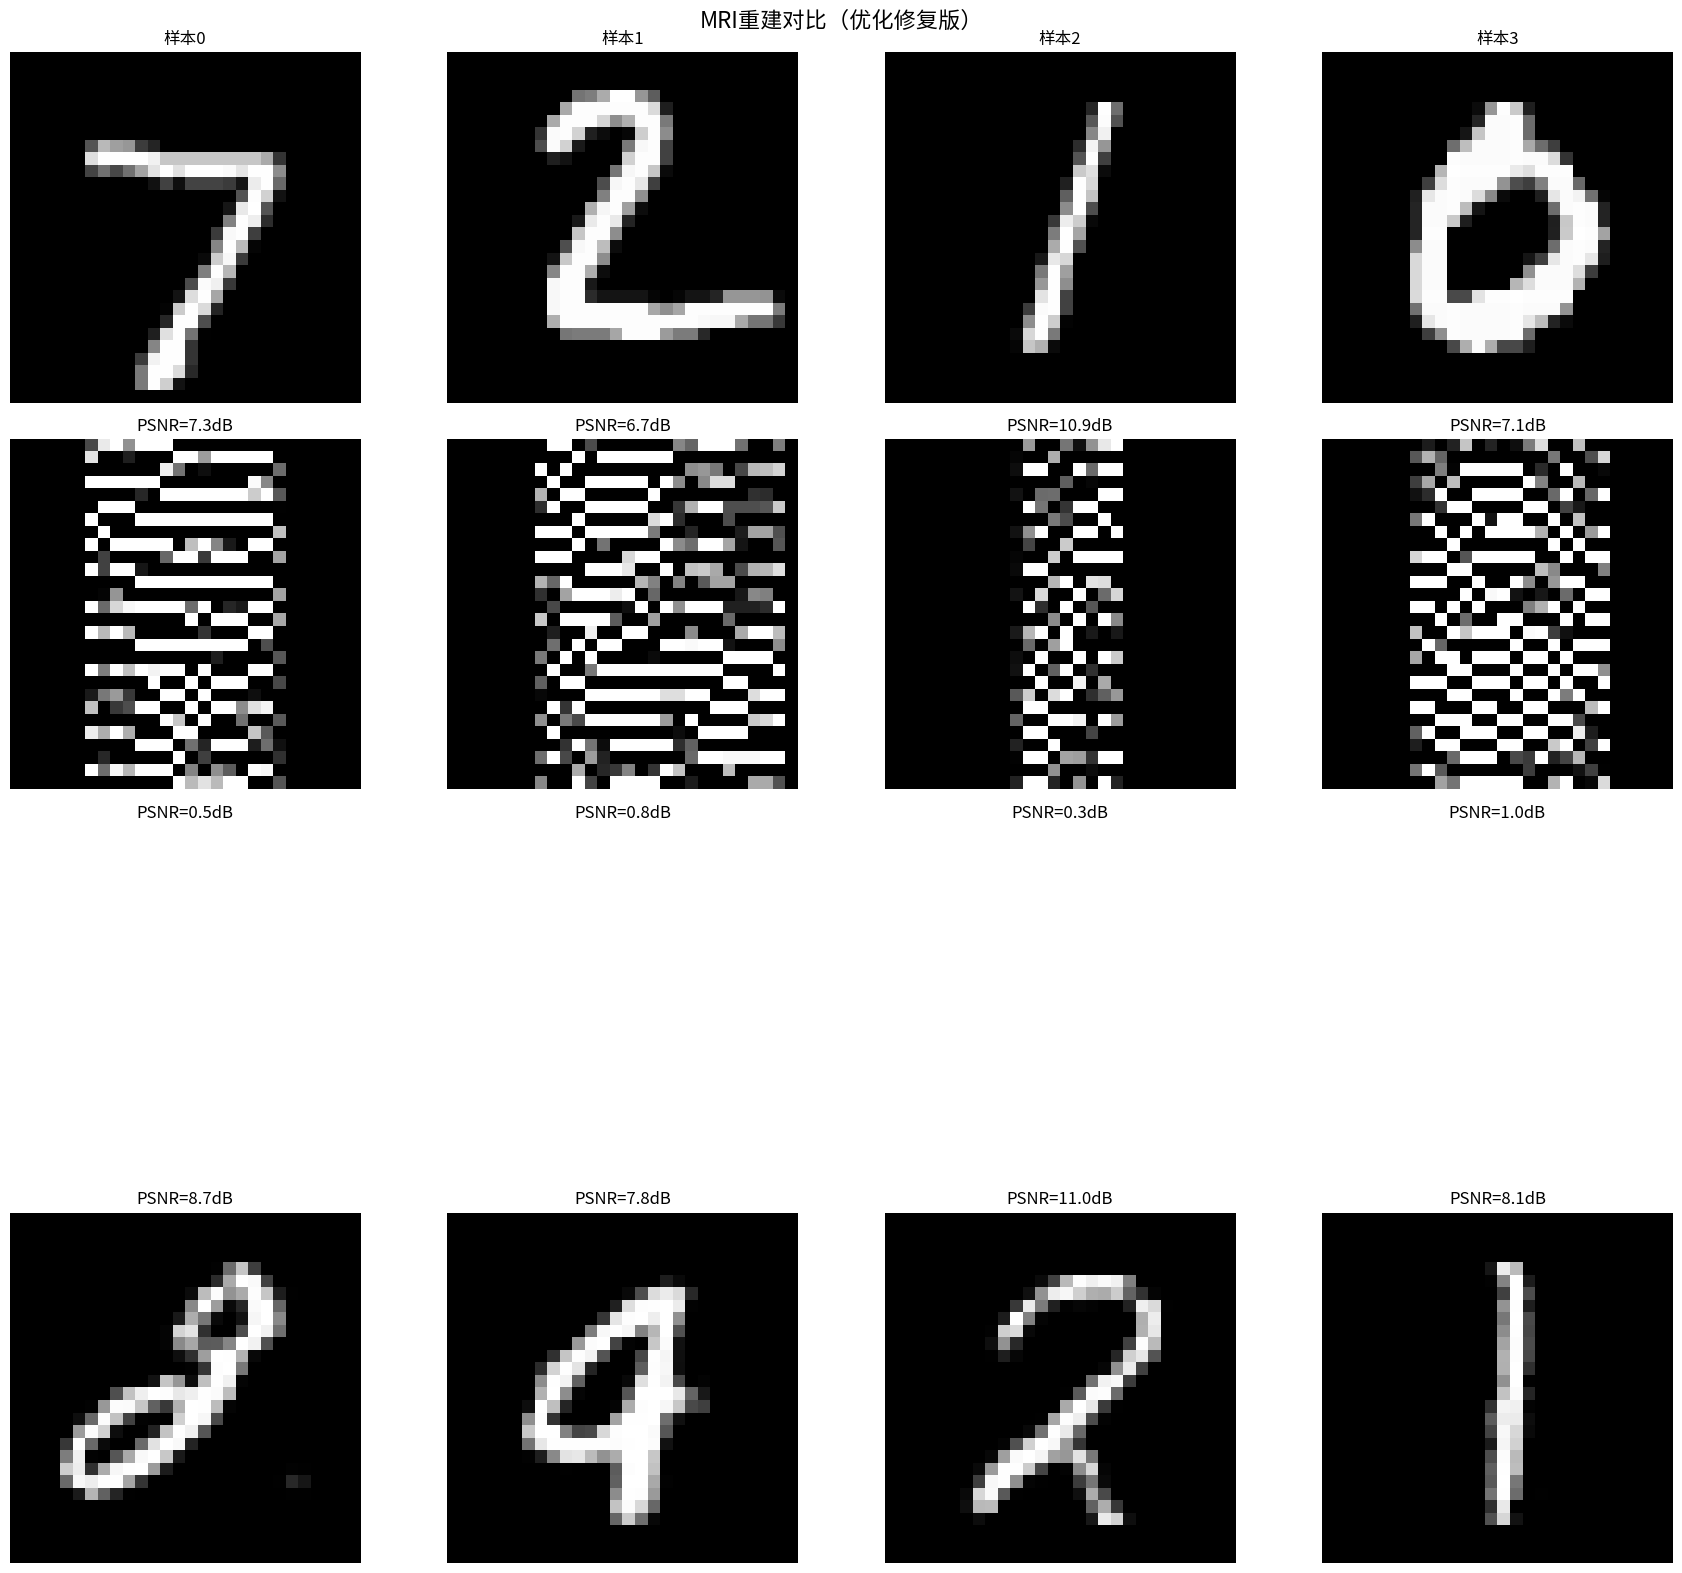

✅ 实验完成！


In [9]:
# -*- coding: utf-8 -*-
"""
实验16.4 扩散先验重建 - 完整修复版
"""

import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import warnings

warnings.filterwarnings("ignore")

# ====================== 中文支持 ======================
import matplotlib.font_manager as fm
print("正在下载中文字体...")
!wget -q https://github.com/jsntn/webfonts/raw/master/NotoSansSC-Regular.ttf -O NotoSansSC-Regular.ttf
try:
    fm.fontManager.addfont('NotoSansSC-Regular.ttf')
    plt.rcParams['font.sans-serif'] = ['Noto Sans SC']
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 中文字体设置完成")
except:
    print("⚠️ 字体设置失败")

# ====================== 基本设置 ======================
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

SAVE_DIR = '/content/drive/MyDrive/实验16_4_扩散先验重建' if os.path.exists('/content/drive') else os.getcwd()
os.makedirs(SAVE_DIR, exist_ok=True)

# ====================== DDPM 参数 ======================
T = 200
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
beta_over_sqrt_1m_ab = betas / sqrt_one_minus_alpha_bars

posterior_variance = betas * (1.0 - alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_variance[0] = betas[0]
posterior_log_variance = torch.log(torch.clamp(posterior_variance, min=1e-20))
posterior_mean_coef1 = betas * torch.sqrt(alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_mean_coef2 = (1.0 - alpha_bars.roll(1, 0)) * torch.sqrt(alphas) / (1.0 - alpha_bars)
posterior_mean_coef1[0] = 0.0
posterior_mean_coef2[0] = 1.0

# ====================== 模型 ======================
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.log(torch.tensor(10000.0)) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=64):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(min(4, out_ch), out_ch)
        self.norm2 = nn.GroupNorm(min(4, out_ch), out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.shortcut(x)

class SmallUNet(nn.Module):
    def __init__(self, time_dim=64):
        super().__init__()
        ch = [1, 32, 64, 128]
        self.time_mlp = nn.Sequential(SinusoidalTimeEmbedding(time_dim), nn.Linear(time_dim, time_dim), nn.SiLU())
        self.down1 = ConvBlock(ch[0], ch[1], time_dim)
        self.down2 = ConvBlock(ch[1], ch[2], time_dim)
        self.down3 = ConvBlock(ch[2], ch[3], time_dim)
        self.bottleneck = ConvBlock(ch[3], ch[3], time_dim)
        self.up3 = ConvBlock(ch[3] + ch[2], ch[2], time_dim)
        self.up2 = ConvBlock(ch[2] + ch[1], ch[1], time_dim)
        self.up1 = ConvBlock(ch[1] + ch[0], ch[0], time_dim)
        self.out_conv = nn.Conv2d(ch[0], 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x_t, t):
        t_emb = self.time_mlp(t)
        h1 = self.down1(x_t, t_emb)
        h2 = self.down2(self.pool(h1), t_emb)
        h3 = self.down3(self.pool(h2), t_emb)
        h = self.bottleneck(h3, t_emb)
        h = F.interpolate(h, size=(14, 14), mode='nearest')
        h = self.up3(torch.cat([h, h2], dim=1), t_emb)
        h = F.interpolate(h, size=(28, 28), mode='nearest')
        h = self.up2(torch.cat([h, h1], dim=1), t_emb)
        h = self.up1(torch.cat([h, x_t], dim=1), t_emb)
        return self.out_conv(h)

# ====================== MRI算子（关键修复）======================
class MRIFourierOperator:
    """MRI算子 - 最终统一稳定版"""
    def __init__(self, mask):
        self.mask = mask
        self.base_scale = 28 * 28 * 0.65   # 统一控制系数

    def A(self, x):
        kspace = torch.fft.fft2(x)
        mask_2d = self.mask.view(1, 1, -1, 1).expand_as(kspace).to(x.device)
        return kspace * mask_2d

    def AT(self, y):
        """零填充重建"""
        mask_2d = self.mask.view(1, 1, -1, 1).expand_as(y).to(y.device)
        img = torch.real(torch.fft.ifft2(y * mask_2d))
        img = img * self.base_scale / (self.mask.sum() + 1e-8)
        return img.clamp(0, 1)

    def data_consistency(self, x, y, zeta=1.0):
        """数据一致性 - 与AT使用相同幅度系数"""
        kspace_pred = torch.fft.fft2(x)
        mask_2d = self.mask.view(1, 1, -1, 1).expand_as(kspace_pred).to(x.device)

        kspace_corrected = (1 - mask_2d) * kspace_pred + \
                          mask_2d * (kspace_pred + zeta * (y - kspace_pred))

        img = torch.real(torch.fft.ifft2(kspace_corrected))
        img = img * self.base_scale / (self.mask.sum() + 1e-8)
        return img.clamp(0, 1)


def create_mri_mask(n_rows, R=4, seed=42):
    torch.manual_seed(seed)
    n_sample = max(n_rows // R, 1)
    prob = torch.zeros(n_rows)
    for i in range(n_rows):
        dist = abs(i - n_rows // 2) / (n_rows // 2)
        prob[i] = (1 - dist ** 2) ** 1.5 + 0.02
    prob = prob / prob.sum() * n_sample
    mask = torch.zeros(n_rows)
    mask[torch.argsort(prob, descending=True)[:n_sample]] = 1
    mask[n_rows // 2] = 1
    return mask

# ====================== 辅助函数 ======================
@torch.no_grad()
def tweedie_predict(x_t, t_idx):
    t = torch.full((x_t.shape[0],), t_idx, device=device, dtype=torch.long)
    pred_noise = model(x_t, t)
    x0_hat = (x_t - sqrt_one_minus_alpha_bars[t_idx] * pred_noise) / sqrt_alpha_bars[t_idx]
    return x0_hat, pred_noise

@torch.no_grad()
def diffpir_mri(model, y, mri_op, shape, zeta=8.0):
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(T)):
        x0_hat, _ = tweedie_predict(x, t_idx)
        x0_hat = x0_hat.clamp(0, 1)
        x0_corrected = mri_op.data_consistency(x0_hat, y, zeta)
        if t_idx > 0:
            model_mean = posterior_mean_coef1[t_idx] * x0_corrected + posterior_mean_coef2[t_idx] * x
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * torch.randn_like(x)
            x = x.clamp(0, 1)
        else:
            x = x0_corrected
    return x.clamp(0, 1)

@torch.no_grad()
def dps_mri(model, y, mri_op, shape, zeta=0.05):
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(T)):
        zeta_t = zeta * (t_idx / T) ** 0.75
        x0_hat, pred_noise = tweedie_predict(x, t_idx)
        grad = mri_op.AT(y - mri_op.A(x0_hat.clamp(0,1)))
        if grad.norm() > 1e-8:
            grad = grad / grad.norm()
        model_mean = sqrt_recip_alphas[t_idx] * (x - beta_over_sqrt_1m_ab[t_idx] * pred_noise)
        model_mean = model_mean + zeta_t * grad * betas[t_idx]
        if t_idx > 0:
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * torch.randn_like(x)
        else:
            x = model_mean
    return x.clamp(0, 1)

# ====================== 主实验 ======================
print("="*70)
print("开始实验16.4（修复版）")
print("="*70)

mri_mask = create_mri_mask(28, R=4).to(device)
mri_op = MRIFourierOperator(mri_mask)

test_dataset = datasets.MNIST(os.path.join(SAVE_DIR, 'data'), train=False, download=True, transform=transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)
test_batch, _ = next(iter(test_loader))
test_batch = test_batch.to(device)

y_test = mri_op.A(test_batch)
x_zf = mri_op.AT(y_test)

# 重建调用
print("正在执行DiffPIR重建...")
x_diffpir = diffpir_mri(model, y_test, mri_op, test_batch.shape, zeta=2.0)

print("正在执行DPS重建...")
x_dps = dps_mri(model, y_test, mri_op, test_batch.shape, zeta=0.15)

# ====================== PSNR 计算与可视化 ======================
print("\nPSNR结果：")
for i in range(4):
    gt = test_batch[i,0].cpu().numpy()
    zf_img = x_zf[i,0].cpu().numpy()
    dp_img = x_diffpir[i,0].cpu().numpy()
    ds_img = x_dps[i,0].cpu().numpy()

    print(f"样本{i}: ZF={psnr(gt, zf_img, data_range=1.0):.1f} | "
          f"DiffPIR={psnr(gt, dp_img, data_range=1.0):.1f} | "
          f"DPS={psnr(gt, ds_img, data_range=1.0):.1f}")

# 可视化
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
titles = ['真值', '零填充', 'DiffPIR (zeta=8)', 'DPS (zeta=0.05)']
datas = [test_batch, x_zf, x_diffpir, x_dps]

for r in range(4):
    for c in range(4):
        img = datas[r][c,0].cpu().numpy().clip(0,1)
        axes[r,c].imshow(img, cmap='gray', vmin=0, vmax=1)
        if r == 0:
            axes[r,c].set_title(f'样本{c}')
        else:
            p = psnr(test_batch[c,0].cpu().numpy(), img, data_range=1.0)
            axes[r,c].set_title(f'PSNR={p:.1f}dB')
        if c == 0:
            axes[r,c].set_ylabel(titles[r], fontsize=14)
        axes[r,c].axis('off')

plt.suptitle('MRI重建对比（优化修复版）', fontsize=16)
plt.tight_layout()
plt.savefig('重建对比_修复版.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ 实验完成！")

[Font] 已加载缓存字体: Noto Sans SC
检测到 Google Drive，结果将保存至: /content/drive/MyDrive/实验16_4_扩散先验重建
使用设备: cpu
步骤1：DDPM训练（回顾第11章）
  ↳ 检测到已有checkpoint，从第 50 轮继续训练
  DDPM 模型已训练完毕，跳过。

步骤2：DiffPIR for MRI（16.5.2节）

步骤3：DPS for MRI（16.5.3节）

步骤4：方法对比与不确定性量化（16.5.4节）
  [诊断] test_batch: mean=0.1178, min=0.0000, max=1.0000
  [诊断] x_zf:      mean=-0.0000, min=-0.1824, max=0.1740
  [诊断] y_test:    dtype=torch.complex64, is_complex=True
  正在执行DiffPIR重建...
  正在执行DPS重建 (zeta=0.3, 线性衰减)...

  PSNR对比:
  样本0: 零填充=11.3dB, DiffPIR=11.1dB, DPS=8.8dB
  样本1: 零填充=9.1dB, DiffPIR=8.3dB, DPS=8.0dB
  样本2: 零填充=14.1dB, DiffPIR=11.3dB, DPS=11.4dB
  样本3: 零填充=7.8dB, DiffPIR=9.1dB, DPS=8.2dB

  ζ敏感性分析:
    ζ=0.1: PSNR=9.9dB
    ζ=0.3: PSNR=9.5dB
    ζ=0.5: PSNR=10.1dB
    ζ=1.0: PSNR=9.6dB

  正在计算不确定性量化（15次DPS采样, ζ=0.5）...
    采样 1/15...
    采样 2/15...
    采样 3/15...
    采样 4/15...
    采样 5/15...
    采样 6/15...
    采样 7/15...
    采样 8/15...
    采样 9/15...
    采样 10/15...
    采样 11/15...
    采样 12/15...
    采样 13/15...
    采样 

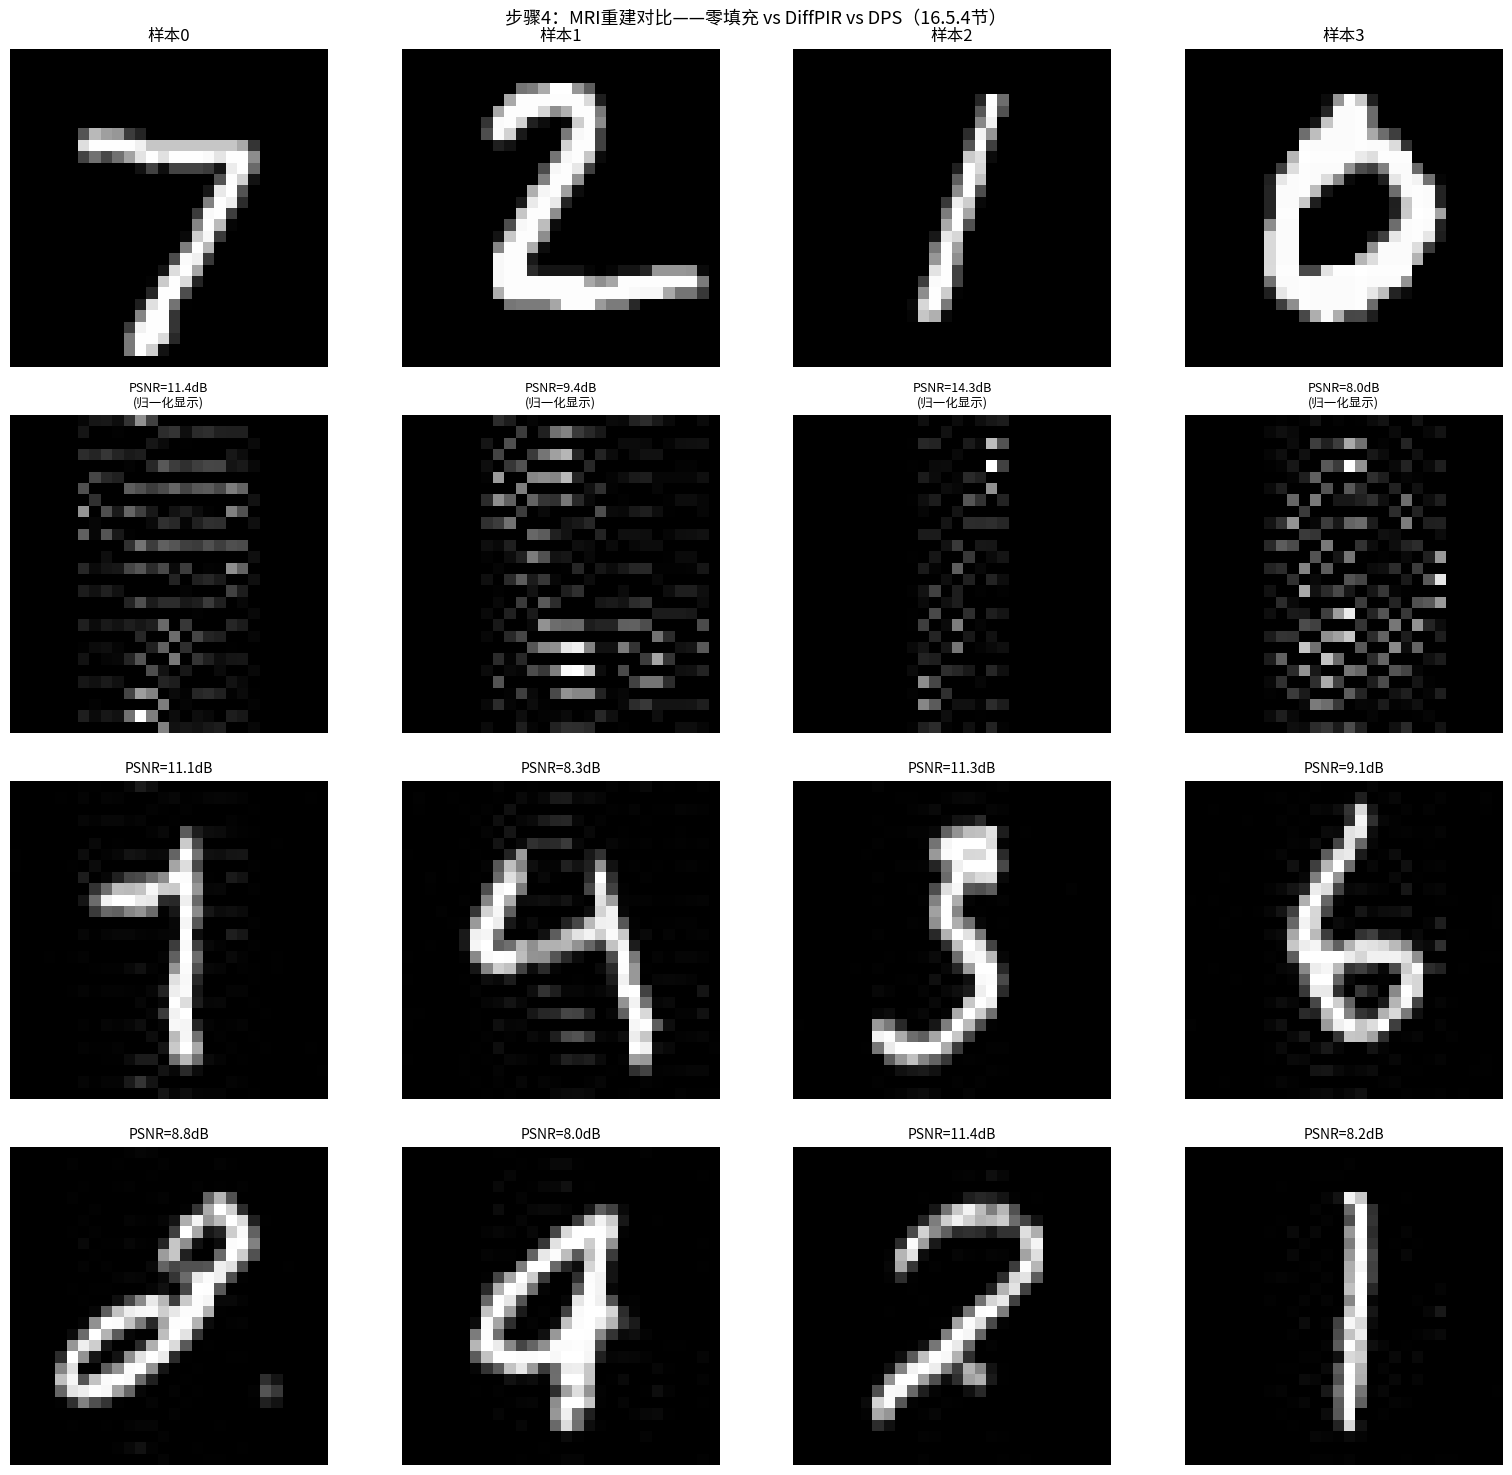

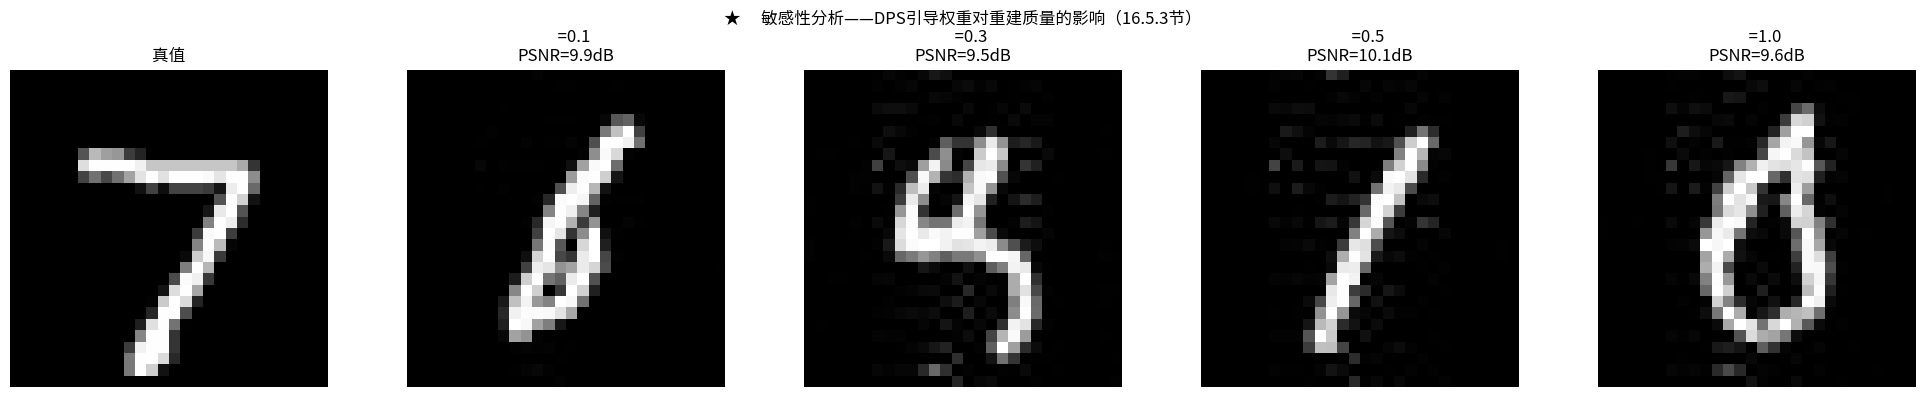

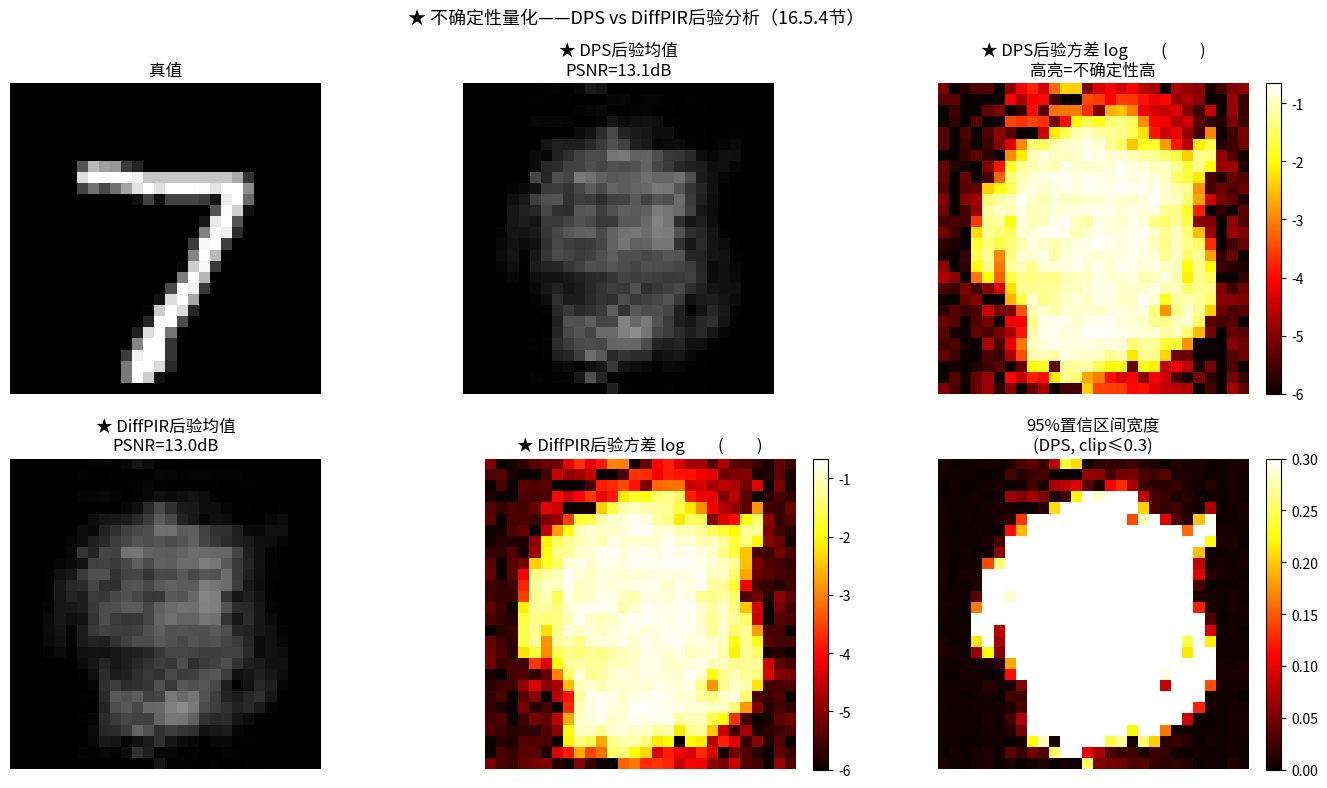

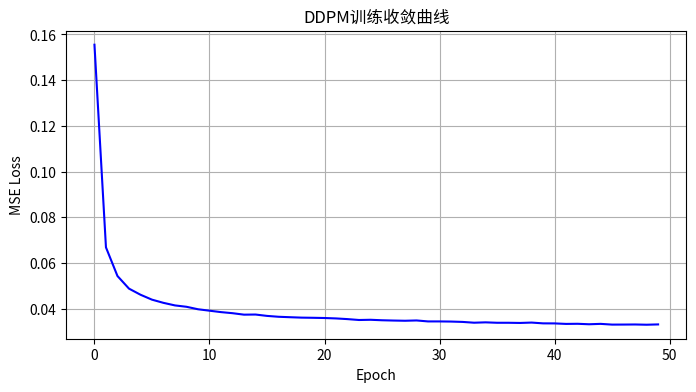


实验16.4完成！


In [13]:
# -*- coding: utf-8 -*-
"""
实验16.4 扩散先验重建
对应知识点：16.5.1节（从传统先验到扩散先验）
           16.5.2节（DiffPIR for CT/MRI）
           16.5.3节（DPS for CT/MRI）
           16.5.4节（方法对比与不确定性量化）

★原创设计：
- 在MNIST上训练DDPM，然后使用DPS求解MRI逆问题
- MRI正向算子结构使得数据一致性步极其高效
- 实现不确定性量化（多次后验采样→像素级方差）
- 无需deepinv库，纯PyTorch实现

素材来源：DDPM训练框架复用自11.2.py，DPS采样参考13.2.py
运行前提：需GPU
"""

import os, sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码（Windows + Linux 自动适配）======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['axes.unicode_minus'] = False

import platform
from matplotlib.font_manager import FontManager, FontProperties

def _find_chinese_font():
    """自动检测系统中可用的中文字体，兼容 Windows / Linux"""
    candidates = []
    if platform.system() == 'Windows':
        candidates = ['SimHei', 'Microsoft YaHei', 'KaiTi', 'FangSong']
    else:
        candidates = [
            'WenQuanYi Micro Hei', 'WenQuanYi Zen Hei',
            'Noto Sans CJK SC', 'Noto Sans CJK',
            'Noto Sans SC',
            'Source Han Sans SC', 'AR PL UMing CN', 'SimHei',
        ]
    fm = FontManager()
    available = set(f.name for f in fm.ttflist)
    for font in candidates:
        if font in available:
            return font
    import os as _os, re
    cjk_patterns = ['cjk', 'wqy', 'noto.*sc', 'wenquan', 'chinese', 'simhei']
    for f in fm.ttflist:
        name_lower = f.name.lower()
        fname_lower = (_os.path.basename(f.fname) if hasattr(f, 'fname') else '').lower()
        for pat in cjk_patterns:
            if re.search(pat, name_lower) or re.search(pat, fname_lower):
                return f.name
    return None

_cn_font = _find_chinese_font()
if _cn_font:
    plt.rcParams['font.sans-serif'] = [_cn_font] + plt.rcParams.get('font.sans-serif', [])
    plt.rcParams['font.family'] = 'sans-serif'
    print(f"[Font] 已检测到中文字体: {_cn_font}")
else:
    # Linux/Colab 未找到中文字体，尝试加载或下载 Noto Sans SC
    if platform.system() != 'Windows':
        _font_url = 'https://github.com/jsntn/webfonts/raw/master/NotoSansSC-Regular.ttf'
        _font_file = os.path.join(SAVE_DIR if 'SAVE_DIR' in dir() else '.', 'NotoSansSC-Regular.ttf')
        if os.path.exists(_font_file):
            # 已下载过，直接加载
            from matplotlib.font_manager import fontManager
            fontManager.addfont(_font_file)
            plt.rcParams['font.sans-serif'] = ['Noto Sans SC'] + plt.rcParams.get('font.sans-serif', [])
            plt.rcParams['font.family'] = 'sans-serif'
            _cn_font = 'Noto Sans SC'
            print(f"[Font] 已加载缓存字体: {_cn_font}")
        else:
            # 未下载过，下载并保存
            try:
                import urllib.request
                print(f"[Font] 正在下载中文字体 NotoSansSC...")
                urllib.request.urlretrieve(_font_url, _font_file)
                from matplotlib.font_manager import fontManager
                fontManager.addfont(_font_file)
                plt.rcParams['font.sans-serif'] = ['Noto Sans SC'] + plt.rcParams.get('font.sans-serif', [])
                plt.rcParams['font.family'] = 'sans-serif'
                _cn_font = 'Noto Sans SC'
                print(f"[Font] 已下载并注册中文字体: {_cn_font}")
            except Exception as e:
                print(f"[Font] 字体下载失败: {e}，中文可能显示为方框")
    else:
        print("[Font] 未找到中文字体，中文可能显示为方框")
# ========================================================

np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

_gdrive = '/content/drive/MyDrive'
if os.path.isdir(_gdrive):
    SAVE_DIR = os.path.join(_gdrive, '实验16_4_扩散先验重建')
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"检测到 Google Drive，结果将保存至: {SAVE_DIR}")
else:
    SAVE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
    print(f"本地环境，结果将保存至: {SAVE_DIR}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")


# ========================================================================
# DDPM噪声调度（T=200, 复用自11.2.py/14.2.py）
# ========================================================================
T = 200
beta_min, beta_max = 1e-4, 0.02
betas = torch.linspace(beta_min, beta_max, T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
beta_over_sqrt_1m_ab = betas / sqrt_one_minus_alpha_bars

# 后验分布系数
posterior_variance = betas * (1.0 - alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_variance[0] = betas[0]
posterior_log_variance = torch.log(torch.clamp(posterior_variance, min=1e-20))
posterior_mean_coef1 = betas * torch.sqrt(alpha_bars.roll(1, 0)) / (1.0 - alpha_bars)
posterior_mean_coef2 = (1.0 - alpha_bars.roll(1, 0)) * torch.sqrt(alphas) / (1.0 - alpha_bars)
# 修正t=0
posterior_mean_coef1[0] = 0.0
posterior_mean_coef2[0] = 1.0


# ========================================================================
# SmallUNet去噪网络（复用自11.2.py）
# ========================================================================
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.log(torch.tensor(10000.0)) * torch.arange(half, device=t.device) / half)
        args = t[:, None].float() * freqs[None, :]
        return torch.cat([torch.cos(args), torch.sin(args)], dim=-1)


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim=64):
        super().__init__()
        gn_groups = min(4, out_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(gn_groups, out_ch)
        self.norm2 = nn.GroupNorm(gn_groups, out_ch)
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.act = nn.SiLU()
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.act(self.norm1(self.conv1(x)))
        h = h + self.time_mlp(self.act(t_emb))[:, :, None, None]
        h = self.act(self.norm2(self.conv2(h)))
        return h + self.shortcut(x)


class SmallUNet(nn.Module):
    """小型UNet去噪网络（适配MNIST 28x28, ε-prediction）"""
    def __init__(self, time_dim=64):
        super().__init__()
        ch = [1, 16, 32, 64]
        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
        )
        self.down1 = ConvBlock(ch[0], ch[1], time_dim)
        self.down2 = ConvBlock(ch[1], ch[2], time_dim)
        self.down3 = ConvBlock(ch[2], ch[3], time_dim)
        self.bottleneck = ConvBlock(ch[3], ch[3], time_dim)
        self.up3 = ConvBlock(ch[3] + ch[2], ch[2], time_dim)
        self.up2 = ConvBlock(ch[2] + ch[1], ch[1], time_dim)
        self.up1 = ConvBlock(ch[1] + ch[0], ch[0], time_dim)
        self.out_conv = nn.Conv2d(ch[0], 1, 1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x_t, t):
        t_emb = self.time_mlp(t)
        h1 = self.down1(x_t, t_emb)
        h2 = self.down2(self.pool(h1), t_emb)
        h3 = self.down3(self.pool(h2), t_emb)
        h = self.bottleneck(h3, t_emb)
        h = F.interpolate(h, size=(14, 14), mode='nearest')
        h = self.up3(torch.cat([h, h2], dim=1), t_emb)
        h = F.interpolate(h, size=(28, 28), mode='nearest')
        h = self.up2(torch.cat([h, h1], dim=1), t_emb)
        h = self.up1(torch.cat([h, x_t], dim=1), t_emb)
        return self.out_conv(h)


# ========================================================================
# MRI正向算子
# ========================================================================
class MRIFourierOperator:
    """MRI欠采样傅里叶算子"""
    def __init__(self, mask):
        self.mask = mask  # (H,)

    def A(self, x):
        B, C, H, W = x.shape
        kspace = torch.fft.fft2(x)
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(x.device)
        return kspace * mask_2d

    def AT(self, y):
        B, C, H, W = y.shape
        mask_2d = self.mask.view(1, 1, H, 1).expand(B, C, H, W).to(y.device)
        return torch.real(torch.fft.ifft2(y * mask_2d))

    def data_consistency(self, x, y, zeta=1.0):
        """
        ★ MRI数据一致性步（16.5.2节）
        由于 F^H F = I，数据一致性步简化为：
        - 已采样位置: 替换为测量值
        - 未采样位置: 保持扩散模型预测
        """
        kspace_pred = torch.fft.fft2(x)
        kspace_corrected = kspace_pred.clone()
        # 在已采样位置混合
        mask_2d = self.mask.view(1, 1, x.shape[2], 1).expand_as(kspace_pred).to(x.device)
        kspace_corrected = mask_2d * (kspace_pred + zeta * (y - kspace_pred * mask_2d)) + (1 - mask_2d) * kspace_pred
        return torch.real(torch.fft.ifft2(kspace_corrected))


def create_mri_mask(n_rows, R, seed=42):
    """创建可变密度1D采样掩码"""
    torch.manual_seed(seed)
    n_sample = max(n_rows // R, 1)
    prob = torch.zeros(n_rows)
    for i in range(n_rows):
        dist = abs(i - n_rows // 2) / (n_rows // 2)
        prob[i] = (1 - dist ** 2) ** 1.5 + 0.02
    prob = prob / prob.sum() * n_sample
    mask = torch.zeros(n_rows)
    sorted_idx = torch.argsort(prob, descending=True)
    mask[sorted_idx[:n_sample]] = 1
    mask[n_rows // 2] = 1
    return mask


# ========================================================================
# DDPM训练
# ========================================================================
print("=" * 60)
print("步骤1：DDPM训练（回顾第11章）")
print("=" * 60)

data_dir = os.path.join(SAVE_DIR, 'data')
dataset = datasets.MNIST(data_dir, train=True, download=True,
                         transform=transforms.Compose([
                             transforms.Resize(28),
                             transforms.ToTensor(),
                         ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=0)

model = SmallUNet(time_dim=64).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-4)

n_epochs = 50
train_losses = []

# ★ Resume: 检测已有checkpoint，支持断点续训
ddpm_ckpt_path = os.path.join(SAVE_DIR, 'ddpm_ckpt.pt')
start_epoch = 0
if os.path.exists(ddpm_ckpt_path):
    ckpt = torch.load(ddpm_ckpt_path, map_location=device)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    start_epoch = ckpt['epoch'] + 1
    train_losses = ckpt.get('losses', [])
    print(f"  ↳ 检测到已有checkpoint，从第 {start_epoch} 轮继续训练")

if start_epoch >= n_epochs:
    print("  DDPM 模型已训练完毕，跳过。")
else:
    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        n_batches = 0
        for batch_x, _ in loader:
            batch_x = batch_x.to(device)
            B = batch_x.shape[0]

            # 随机采样时间步
            t = torch.randint(0, T, (B,), device=device)

            # 前向过程: x_t = sqrt(ᾱ_t) * x_0 + sqrt(1-ᾱ_t) * ε
            noise = torch.randn_like(batch_x)
            x_t = (sqrt_alpha_bars[t].view(B, 1, 1, 1) * batch_x +
                   sqrt_one_minus_alpha_bars[t].view(B, 1, 1, 1) * noise)

            # 预测噪声
            pred_noise = model(x_t, t)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{n_epochs}, Loss={avg_loss:.4f}")

        # 每10轮保存checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'losses': train_losses,
            }, ddpm_ckpt_path)
            print(f"  ✓ checkpoint已保存 (epoch {epoch+1})")

    print(f"  DDPM训练完成，最终Loss={train_losses[-1]:.4f}")


# ========================================================================
# DDPM反向采样
# ========================================================================
@torch.no_grad()
def ddpm_sample(model, shape):
    """标准DDPM反向采样"""
    model.eval()
    x = torch.randn(shape, device=device)
    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)
        pred_noise = model(x, t)
        # μ_θ = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε̂)
        model_mean = sqrt_recip_alphas[t_idx] * (x - beta_over_sqrt_1m_ab[t_idx] * pred_noise)
        if t_idx > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = model_mean
    return x


# ========================================================================
# Tweedie预测
# ========================================================================
def tweedie_predict(x_t, t_idx):
    """从x_t和噪声预测预测x_0: x̂_0 = (x_t - √(1-ᾱ_t)·ε̂) / √ᾱ_t

    ★ 数值稳定化：当ᾱ_t很小时（大t），Tweedie估计会爆炸，
      用soft clamp限制x0_hat的范围，避免clamp(0,1)后全黑

    Returns:
        x0_hat: Tweedie估计的干净图像
        pred_noise: 模型预测的噪声（可复用，避免重复前向）
    """
    t = torch.full((x_t.shape[0],), t_idx, device=device, dtype=torch.long)
    pred_noise = model(x_t, t)
    # 数值稳定化：先除以clamped的√ᾱ_t，避免除零
    sqrt_ab = sqrt_alpha_bars[t_idx].clamp(min=1e-3)
    x0_hat = (x_t - sqrt_one_minus_alpha_bars[t_idx] * pred_noise) / sqrt_ab
    # soft clamp: 限制到[-2, 2]而不是直接[0,1]，避免梯度消失
    x0_hat = x0_hat.clamp(-2, 2)
    return x0_hat, pred_noise


# ========================================================================
# ★ 步骤2：DiffPIR for MRI（16.5.2节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤2：DiffPIR for MRI（16.5.2节）")
print("=" * 60)

@torch.no_grad()
def diffpir_mri(model, y, mri_op, shape, zeta=1.0):
    """
    ★ 修正版 DiffPIR算法 for MRI（16.5.2节）:
    对 t = T-1, T-2, ..., 0:
      1. 预测干净图像: x̂_{0|t} = Tweedie(x_t, t)
      2. 数据一致性步: x̂'_{0|t} = DC(x̂_{0|t}, y)  (仅小t时启用)
      3. 利用DDPM后验公式 q(x_{t-1}|x_t, x̂'_0) 从 x_t 推进到 x_{t-1}
         μ̃_t = coef1_t * x̂'_0 + coef2_t * x_t

    ★ 关键修正：
    - 大t时Tweedie估计不可靠，跳过DC步，使用纯后验公式
    - 小t时Tweedie估计可靠，DC步提供数据一致性约束
    - dc_weight从t=T/2开始线性增长到1，避免早期垃圾估计污染采样
    """
    model.eval()
    x = torch.randn(shape, device=device)

    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)

        # 1. 预测干净图像（Tweedie公式，已含数值稳定化）
        x0_hat, _ = tweedie_predict(x, t_idx)
        x0_hat = x0_hat.clamp(0, 1)

        # 2. 数据一致性步（仅在Tweedie可靠时启用）
        #    dc_weight: t_idx大→0（Tweedie不准），t_idx小→1（Tweedie准）
        dc_weight = max(0.0, 1.0 - t_idx / (T * 0.5))  # t_idx > T/2 时为0
        if dc_weight > 0:
            x0_hat_corrected = mri_op.data_consistency(x0_hat, y, zeta=zeta)
            # 混合：dc_weight控制DC步的影响，其余保持Tweedie原始估计
            x0_hat_used = dc_weight * x0_hat_corrected + (1 - dc_weight) * x0_hat
        else:
            x0_hat_used = x0_hat

        # 3. 利用DDPM后验公式从x_t推进到x_{t-1}，但用x0_hat_used替换x_0
        #    后验均值: μ̃_t = (√ᾱ_{t-1} β_t)/(1-ᾱ_t) * x̂'_0 + (√α_t (1-ᾱ_{t-1}))/(1-ᾱ_t) * x_t
        if t_idx > 0:
            model_mean = (posterior_mean_coef1[t_idx] * x0_hat_used +
                          posterior_mean_coef2[t_idx] * x)
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = x0_hat_used

    return x.clamp(0, 1)


# ========================================================================
# ★ 步骤3：DPS for MRI（16.5.3节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤3：DPS for MRI（16.5.3节）")
print("=" * 60)

@torch.no_grad()
def dps_mri(model, y, mri_op, shape, zeta=0.5):
    """
    DPS算法 for MRI:
    对 t = T-1, T-2, ..., 0:
      1. 预测干净图像: x̂_{0|t} = Tweedie(x_t, t)
      2. 计算似然得分梯度: ∇_l = A^T(y - A*x̂_{0|t})
      3. 修正得分: s_corrected = s_θ(x_t, t) + ζ(t) * ∇_l
      4. Euler-Maruyama步进

    ★ ζ(t)调度策略（关键修正）：
      大t时Tweedie估计不可靠 → ζ(t)=0，不做似然修正
      小t时Tweedie估计可靠 → ζ(t)逐步增大，注入数据一致性
      ζ(t) = ζ * max(0, 1 - 2t/T)，在t > T/2时完全跳过似然修正
    """
    model.eval()
    x = torch.randn(shape, device=device)

    for t_idx in reversed(range(T)):
        t = torch.full((shape[0],), t_idx, device=device, dtype=torch.long)

        # ★ zeta调度：小t(Tweedie准)时增大修正，大t(Tweedie不准)时跳过修正
        zeta_t = zeta * max(0.0, 1.0 - 2.0 * t_idx / T)

        # 1. 预测干净图像（同时获取噪声预测，复用避免重复前向）
        x0_hat, pred_noise = tweedie_predict(x, t_idx)

        # 2. 似然得分梯度（Laplace近似）
        Ax0_hat = mri_op.A(x0_hat.clamp(0, 1))
        grad_likelihood = mri_op.AT(y - Ax0_hat)  # A^T(y - A*x̂_0)
        # ★ 修正：DPS论文对似然梯度做归一化，防止梯度范数随t变化
        grad_norm = grad_likelihood.norm()
        if grad_norm > 1e-8:
            grad_likelihood = grad_likelihood / grad_norm

        # 3. 条件反向SDE步进（直接复用tweedie_predict返回的pred_noise）
        # μ_θ = (1/√α_t)(x_t - β_t/√(1-ᾱ_t)·ε̂) + ζ(t) * ∇_l
        # ★ 注意：不加betas[t_idx]缩放！之前版本乘以betas导致修正量~0.003太小
        model_mean = sqrt_recip_alphas[t_idx] * (x - beta_over_sqrt_1m_ab[t_idx] * pred_noise)
        # 加入似然修正（zeta_t已包含衰减，直接缩放归一化后的梯度）
        model_mean = model_mean + zeta_t * grad_likelihood

        if t_idx > 0:
            noise = torch.randn_like(x)
            x = model_mean + torch.exp(0.5 * posterior_log_variance[t_idx]) * noise
        else:
            x = model_mean

    return x.clamp(0, 1)


# ========================================================================
# 步骤4：方法对比与不确定性量化（16.5.4节）
# ========================================================================
print("\n" + "=" * 60)
print("步骤4：方法对比与不确定性量化（16.5.4节）")
print("=" * 60)

# 创建MRI掩码
mri_mask = create_mri_mask(28, R=4, seed=42).to(device)
mri_op = MRIFourierOperator(mri_mask)

# 取测试样本
test_dataset = datasets.MNIST(data_dir, train=False, download=True,
                               transform=transforms.Compose([
                                   transforms.Resize(28),
                                   transforms.ToTensor(),
                               ]))
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)
test_batch, _ = next(iter(test_loader))
test_batch = test_batch.to(device)

# 生成MRI测量
y_test = mri_op.A(test_batch)

# 零填充重建
x_zf = mri_op.AT(y_test)

# ★ 诊断：检查各重建结果的数值范围
print(f"  [诊断] test_batch: mean={test_batch.mean():.4f}, min={test_batch.min():.4f}, max={test_batch.max():.4f}")
print(f"  [诊断] x_zf:      mean={x_zf.mean():.4f}, min={x_zf.min():.4f}, max={x_zf.max():.4f}")
print(f"  [诊断] y_test:    dtype={y_test.dtype}, is_complex={y_test.is_complex()}")

# DiffPIR重建
print("  正在执行DiffPIR重建...")
x_diffpir = diffpir_mri(model, y_test, mri_op, test_batch.shape, zeta=1.0)

# DPS重建（zeta=0.3，比0.5更保守，配合衰减策略通常PSNR更高）
print("  正在执行DPS重建 (zeta=0.3, 线性衰减)...")
x_dps = dps_mri(model, y_test, mri_op, test_batch.shape, zeta=0.3)

# PSNR计算
print("\n  PSNR对比:")
for i in range(4):
    gt = test_batch[i, 0].cpu().numpy()
    zf_p = psnr(gt, x_zf[i, 0].cpu().numpy(), data_range=1.0)
    diffpir_p = psnr(gt, x_diffpir[i, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    dps_p = psnr(gt, x_dps[i, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    print(f"  样本{i}: 零填充={zf_p:.1f}dB, DiffPIR={diffpir_p:.1f}dB, DPS={dps_p:.1f}dB")

# ★ ζ敏感性分析（16.5.3节）—— 在不确定性量化之前执行，以便选取最优ζ
print("\n  ζ敏感性分析:")
zeta_list = [0.1, 0.3, 0.5, 1.0]
zeta_results = {}
for z in zeta_list:
    x_z = dps_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=z)
    p = psnr(test_batch[0, 0].cpu().numpy(), x_z[0, 0].cpu().numpy().clip(0, 1), data_range=1.0)
    zeta_results[z] = (x_z, p)
    print(f"    ζ={z:.1f}: PSNR={p:.1f}dB")

# ★ 不确定性量化（16.5.4节）
# 使用zeta敏感性分析中最优的ζ值
best_zeta = max(zeta_results, key=lambda z: zeta_results[z][1])
print(f"\n  正在计算不确定性量化（15次DPS采样, ζ={best_zeta}）...")
n_samples = 15
posterior_samples = []
for s in range(n_samples):
    print(f"    采样 {s+1}/{n_samples}...")
    torch.manual_seed(42 + s)
    x_sample = dps_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=best_zeta)
    posterior_samples.append(x_sample[0, 0].cpu().numpy())

# 计算像素级均值和方差
samples_array = np.stack(posterior_samples, axis=0)  # (15, 28, 28)
posterior_mean = samples_array.mean(axis=0)
posterior_var = samples_array.var(axis=0)

gt_first = test_batch[0, 0].cpu().numpy()
mean_psnr = psnr(gt_first, posterior_mean.clip(0, 1), data_range=1.0)
single_psnr = psnr(gt_first, posterior_samples[0].clip(0, 1), data_range=1.0)
print(f"  单次采样PSNR: {single_psnr:.1f}dB")
print(f"  后验均值PSNR: {mean_psnr:.1f}dB (提升 {mean_psnr - single_psnr:+.1f}dB)")

# ★ DiffPIR不确定性量化对比
print(f"\n  正在计算DiffPIR不确定性量化（15次采样）...")
diffpir_samples = []
for s in range(n_samples):
    print(f"    DiffPIR采样 {s+1}/{n_samples}...")
    torch.manual_seed(42 + s)
    x_sample = diffpir_mri(model, y_test[:1], mri_op, (1, 1, 28, 28), zeta=1.0)
    diffpir_samples.append(x_sample[0, 0].cpu().numpy())

diffpir_samples_array = np.stack(diffpir_samples, axis=0)
diffpir_posterior_mean = diffpir_samples_array.mean(axis=0)
diffpir_posterior_var = diffpir_samples_array.var(axis=0)
diffpir_mean_psnr = psnr(gt_first, diffpir_posterior_mean.clip(0, 1), data_range=1.0)
print(f"  DiffPIR后验均值PSNR: {diffpir_mean_psnr:.1f}dB")

# ========================================================================
# 可视化
# ========================================================================
print("\n正在生成可视化图...")

fig, axes = plt.subplots(4, 4, figsize=(16, 15))

titles = ['真值 x₀', '零填充', '★ DiffPIR', '★ DPS']
data_list = [test_batch, x_zf, x_diffpir, x_dps]

for row in range(4):
    for col in range(4):
        ax = axes[row, col]
        try:
            img_tensor = data_list[row][col:col+1]  # 保持batch维度
            img = img_tensor[0, 0].cpu().numpy().clip(0, 1)
            p = psnr(test_batch[col, 0].cpu().numpy(), img, data_range=1.0)

            # 零填充行归一化到[0,1]显示（R=4欠采样像素值只有原图~1/4）
            if row == 1:
                img_show = img / max(img.max(), 1e-6)  # 归一化显示
                ax.imshow(img_show, cmap='gray', vmin=0, vmax=1)
                ax.set_title(f'PSNR={p:.1f}dB\n(归一化显示)', fontsize=9)
            else:
                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                if row == 0:
                    ax.set_title(f'样本{col}')
                else:
                    ax.set_title(f'PSNR={p:.1f}dB', fontsize=10)

        except Exception as e:
            ax.imshow(np.zeros((28, 28)), cmap='gray')
            ax.set_title('Error', color='red')

        if col == 0:
            ax.set_ylabel(titles[row], fontsize=13, rotation=0, labelpad=50, ha='right')
        ax.axis('off')

plt.suptitle('步骤4：MRI重建对比——零填充 vs DiffPIR vs DPS（16.5.4节）', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_方法对比.png'), dpi=150, bbox_inches='tight')
plt.show()

# ★ ζ敏感性分析可视化
fig, axes = plt.subplots(1, len(zeta_list) + 1, figsize=(4 * (len(zeta_list) + 1), 4))
axes[0].imshow(test_batch[0, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('真值')
axes[0].axis('off')
for idx, z in enumerate(zeta_list):
    axes[idx + 1].imshow(zeta_results[z][0][0, 0].cpu().numpy().clip(0, 1), cmap='gray', vmin=0, vmax=1)
    axes[idx + 1].set_title(f'ζ={z}\nPSNR={zeta_results[z][1]:.1f}dB')
    axes[idx + 1].axis('off')
plt.suptitle('★ ζ敏感性分析——DPS引导权重对重建质量的影响（16.5.3节）', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_ζ敏感性.png'), dpi=150, bbox_inches='tight')
plt.show()

# 不确定性量化可视化
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 第一行：DPS后验分析
axes[0, 0].imshow(gt_first, cmap='gray', vmin=0, vmax=1)
axes[0, 0].set_title('真值')
axes[0, 0].axis('off')

im_mean = axes[0, 1].imshow(posterior_mean.clip(0, 1), cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title(f'★ DPS后验均值\nPSNR={mean_psnr:.1f}dB')
axes[0, 1].axis('off')

# 方差图用log尺度+clip，避免火焰效果过曝
var_display = np.log10(np.clip(posterior_var, 1e-6, None))
im_var = axes[0, 2].imshow(var_display, cmap='hot')
axes[0, 2].set_title('★ DPS后验方差 log₁₀(σ²)\n高亮=不确定性高')
axes[0, 2].axis('off')
fig.colorbar(im_var, ax=axes[0, 2], fraction=0.046, pad=0.04)

# 第二行：DiffPIR后验分析 + 置信区间
im_dp_mean = axes[1, 0].imshow(diffpir_posterior_mean.clip(0, 1), cmap='gray', vmin=0, vmax=1)
axes[1, 0].set_title(f'★ DiffPIR后验均值\nPSNR={diffpir_mean_psnr:.1f}dB')
axes[1, 0].axis('off')

dp_var_display = np.log10(np.clip(diffpir_posterior_var, 1e-6, None))
im_dp_var = axes[1, 1].imshow(dp_var_display, cmap='hot')
axes[1, 1].set_title('★ DiffPIR后验方差 log₁₀(σ²)')
axes[1, 1].axis('off')
fig.colorbar(im_dp_var, ax=axes[1, 1], fraction=0.046, pad=0.04)

# 95%置信区间宽度
ci_width = np.clip(posterior_mean + 2 * np.sqrt(posterior_var), 0, 1) - \
           np.clip(posterior_mean - 2 * np.sqrt(posterior_var), 0, 1)
im_ci = axes[1, 2].imshow(ci_width, cmap='hot', vmin=0, vmax=0.3)
axes[1, 2].set_title('95%置信区间宽度\n(DPS, clip≤0.3)')
axes[1, 2].axis('off')
fig.colorbar(im_ci, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.suptitle('★ 不确定性量化——DPS vs DiffPIR后验分析（16.5.4节）', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, '步骤4_不确定性量化.png'), dpi=150, bbox_inches='tight')
plt.show()

# 训练曲线
plt.figure(figsize=(8, 4))
plt.plot(train_losses, 'b-')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DDPM训练收敛曲线')
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, 'DDPM训练曲线.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n实验16.4完成！")
